# 08. Análisis Cualitativo y Visualización de Embeddings (Fase 6)

Este cuaderno implementa la **Fase 6** del Trabajo de Fin de Máster (TFM). El objetivo de esta fase es:
1. **Reducción de Dimensionalidad**: Proyectar los embeddings de 128 dimensiones generados por la Candidate Tower (Torre de Candidatos) en un espacio de 2D utilizando dos técnicas populares: **t-SNE** (para relaciones locales) y **UMAP** (para la preservación de la estructura global).
2. **Visualización de Macro-Clusters**: Graficar todos los productos activos y colorearlos según la categoría superior (`familia1`) para verificar si el espacio vectorial agrupa a los productos coherentes.
3. **Análisis de Clusters Constructivos**: Seleccionar productos de familias complementarias y validar cuantitativamente (mediante similitud coseno) y cualitativamente si el modelo aprendió sinergias constructivas (por ejemplo, que las tuberías de PVC se ubiquen cerca del pegamento para PVC y el teflón).


In [1]:
import numpy as np
import polars as pl
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 10]
np.random.seed(42)


## 1. Cargar Datos y Alinear Metadata

Cargamos los embeddings de candidatos precalculados, los IDs de los candidatos y el catálogo de productos.


In [2]:
# Cargar datos
embeddings = np.load("models/candidate_embeddings.npy")
candidate_ids = np.load("models/candidate_ids.npy", allow_pickle=True)
catalog = pl.read_parquet("data_processed/products_catalog.parquet").unique(subset=["id_producto"])

print(f"Embeddings de candidatos: {embeddings.shape[0]:,} productos con dimensión {embeddings.shape[1]}")
print(f"Catálogo de productos: {catalog.height:,} registros únicos")


Embeddings de candidatos: 20,683 productos con dimensión 128
Catálogo de productos: 20,683 registros únicos


In [3]:
# Imputar nulos en variables categóricas
catalog = catalog.with_columns([
    pl.col("familia1").fill_null("SIN_CATEGORIA"),
    pl.col("familia2").fill_null("SIN_SUBCATEGORIA"),
    pl.col("marca").fill_null("SIN_MARCA")
])

# Crear DataFrame que represente el orden exacto de los embeddings
ids_df = pl.DataFrame({
    "id_producto": candidate_ids,
    "embedding_idx": np.arange(len(candidate_ids))
})

# Alinear la metadata usando join
aligned_df = ids_df.join(catalog, on="id_producto", how="left")

# Rellenar productos que no tengan match en catálogo
aligned_df = aligned_df.with_columns([
    pl.col("familia1").fill_null("SIN_CATEGORIA"),
    pl.col("familia2").fill_null("SIN_SUBCATEGORIA"),
    pl.col("descripción corta").fill_null("PRODUCTO_DESCONOCIDO")
])

print(f"Forma del catálogo alineado con embeddings: {aligned_df.shape}")


Forma del catálogo alineado con embeddings: (20683, 15)


## 2. Reducción de Dimensionalidad (t-SNE y UMAP)

Para optimizar el tiempo de ejecución en re-ejecuciones, el cuaderno carga coordenadas precalculadas si existen en disco, y si no, ejecuta los algoritmos desde cero.


In [4]:
# Las proyecciones se recalculan siempre a partir de los embeddings vigentes: son
# un artefacto derivado del modelo y almacenarlas en disco las desincronizaría de su
# fuente sin que nada lo advierta. El costo de recomputarlas es de un par de minutos.
print("Calculando t-SNE sobre", embeddings.shape[0], "embeddings...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=-1)
coords_tsne = tsne.fit_transform(embeddings)
np.save("models/coords_tsne.npy", coords_tsne)

print("Calculando UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.15, n_components=2, random_state=42)
coords_umap = reducer.fit_transform(embeddings)
np.save("models/coords_umap.npy", coords_umap)

assert coords_tsne.shape[0] == embeddings.shape[0] == aligned_df.height, \
    "Las proyecciones y la metadata deben describir el mismo conjunto de productos"
print(f"Proyecciones listas: t-SNE {coords_tsne.shape}, UMAP {coords_umap.shape}")

Calculando t-SNE sobre 20683 embeddings...


Calculando UMAP...


/Users/allan/Documents/maestria/tesis v4/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Proyecciones listas: t-SNE (20683, 2), UMAP (20683, 2)


## 3. Visualización de Macro-Clusters

Graficamos los embeddings proyectados colored por la variable `familia1` (categoría de nivel superior) para observar la estructura general del espacio latente.


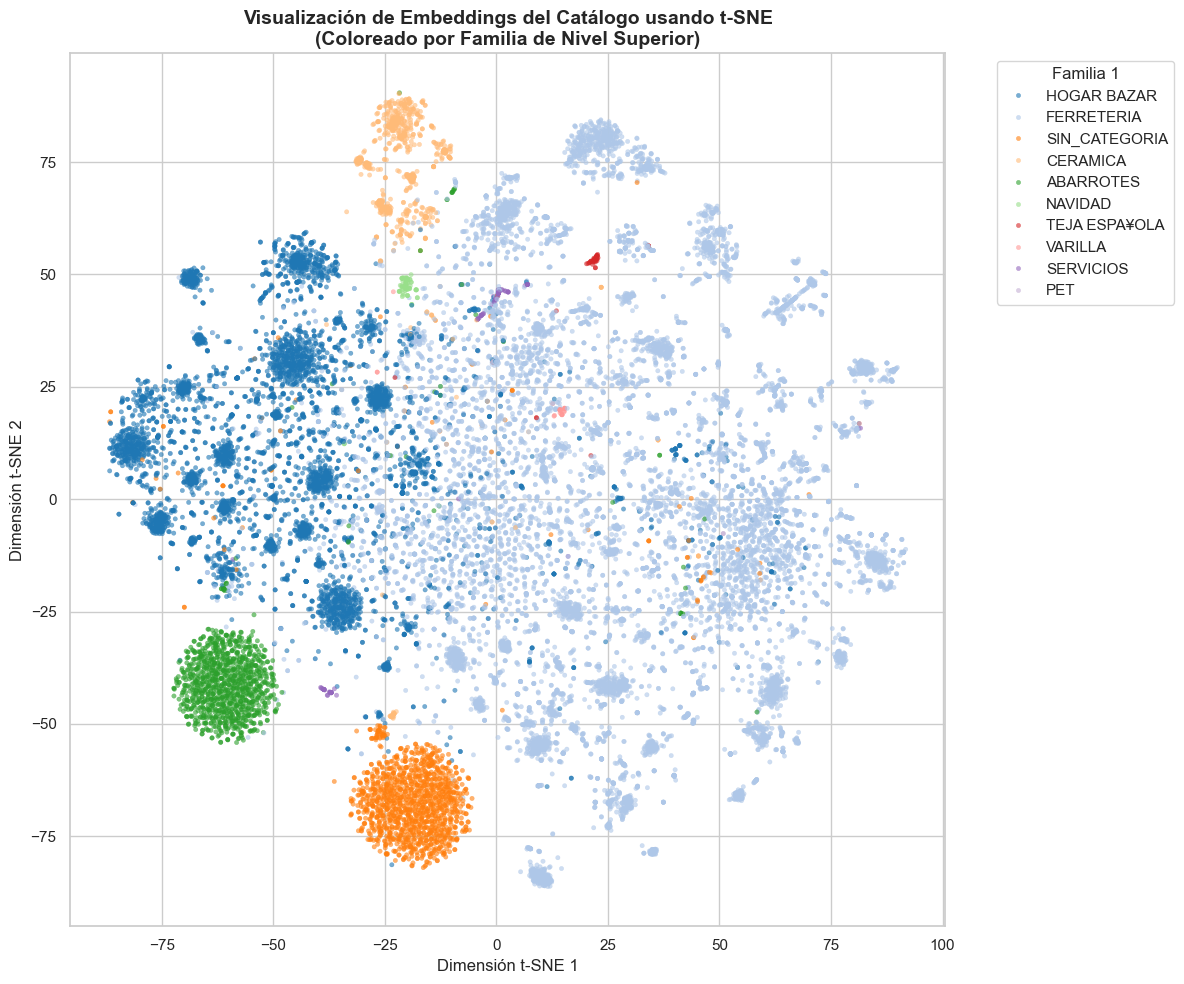

In [5]:
# Familias de nivel superior
families = aligned_df["familia1"].to_list()

# Graficar t-SNE
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=coords_tsne[:, 0], y=coords_tsne[:, 1],
    hue=families,
    palette="tab20",
    alpha=0.6,
    edgecolor=None,
    s=10
)
plt.title("Visualización de Embeddings del Catálogo usando t-SNE\n(Coloreado por Familia de Nivel Superior)", fontsize=14, fontweight="bold")
plt.xlabel("Dimensión t-SNE 1")
plt.ylabel("Dimensión t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Familia 1")
plt.tight_layout()
plt.tight_layout()
plt.savefig("models/tsne_families.png", dpi=300, bbox_inches="tight")
plt.show()


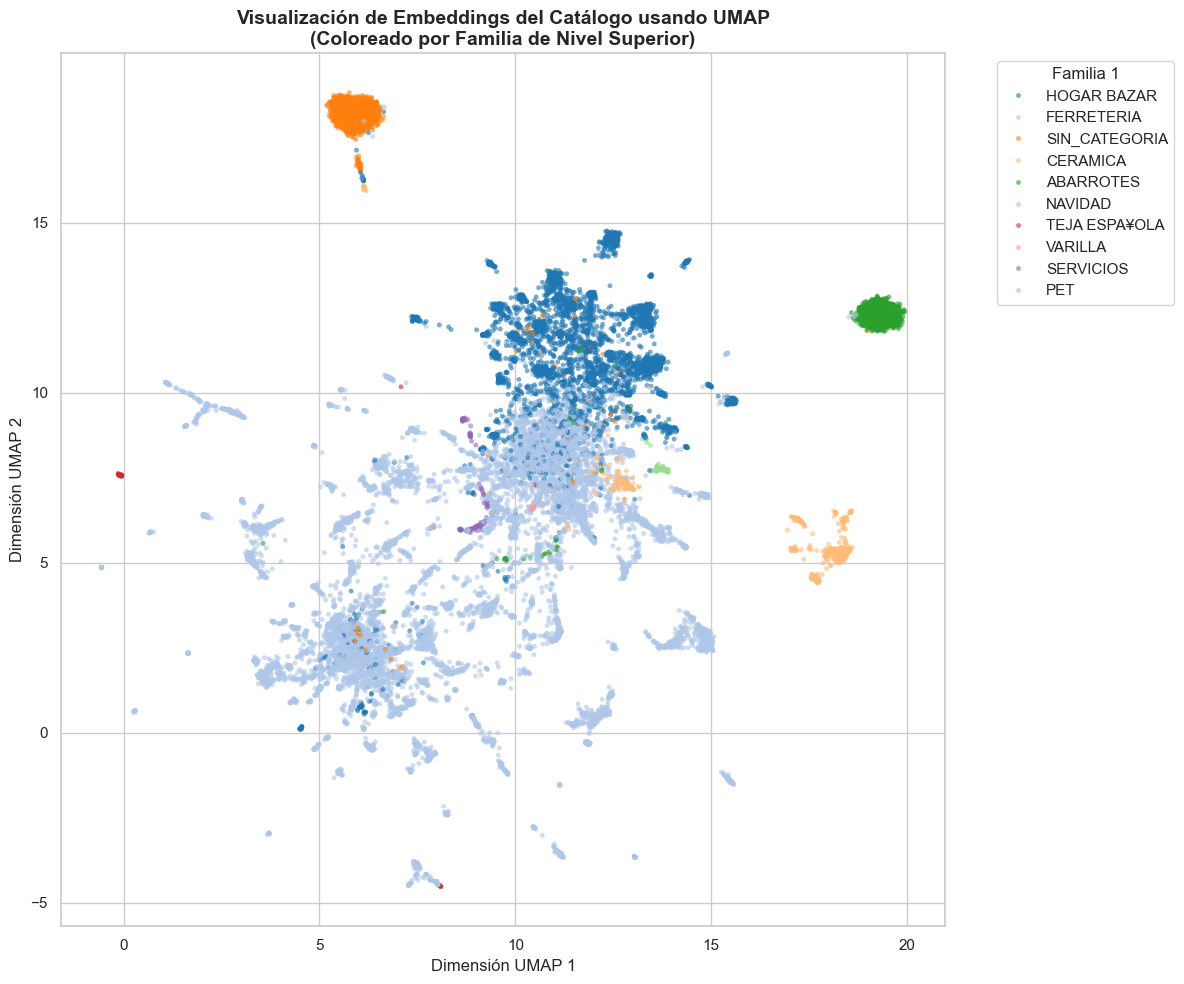

In [6]:
# Graficar UMAP
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=coords_umap[:, 0], y=coords_umap[:, 1],
    hue=families,
    palette="tab20",
    alpha=0.6,
    edgecolor=None,
    s=10
)
plt.title("Visualización de Embeddings del Catálogo usando UMAP\n(Coloreado por Familia de Nivel Superior)", fontsize=14, fontweight="bold")
plt.xlabel("Dimensión UMAP 1")
plt.ylabel("Dimensión UMAP 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Familia 1")
plt.tight_layout()
plt.tight_layout()
plt.savefig("models/umap_families.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Análisis de Clusters Constructivos

Evaluamos cuantitativamente si el espacio de embeddings del recomendador Two Towers es capaz de agrupar elementos que son complementarios en la construcción.
Para ello extraemos representantes típicos de tres áreas ferreteras críticas:
1. **Plumbing (Tuberías y Pegamento PVC)**
2. **Masonry (Obra Gris: Cemento, Aditivos, Acero)**
3. **Electrical (Cables, Tomacorrientes, Cintas)**

Calcularemos la similitud coseno entre ellos y generaremos un mapa de calor.


In [7]:
# La selección se ordena por identificador de producto para que los representantes
# de cada grupo sean siempre los mismos: el orden de unique() de Polars no está
# garantizado y sin este criterio las métricas de similitud no serían reproducibles.
# PVC/Tuberías
pvc_tube = aligned_df.filter(
    pl.col("familia2") == "TUBERIAS Y ACCESORIOS",
    pl.col("descripción corta").str.contains("(?i)tubo.*pvc|tubo.*desag")
).sort("id_producto").head(3)

pvc_elbow = aligned_df.filter(
    pl.col("familia2") == "TUBERIAS Y ACCESORIOS",
    pl.col("descripción corta").str.contains("(?i)codo|union|tee")
).sort("id_producto").head(3)

pvc_glue = aligned_df.filter(
    pl.col("familia2") == "PEGAMENTOS Y ADHESIVOS",
    pl.col("descripción corta").str.contains("(?i)soldadura.*pvc|pega.*pvc")
).sort("id_producto").head(3)

# Cemento y Obra Gris
cement = aligned_df.filter(
    pl.col("descripción corta").str.contains("(?i)cemento.*gris|cemento.*chimborazo|cemento.*selvalegre")
).sort("id_producto").head(3)

rebar = aligned_df.filter(
    pl.col("familia2") == "TREFILADOS Y MALLAS",
    pl.col("descripción corta").str.contains("(?i)alambre|malla|varilla")
).sort("id_producto").head(3)

sika = aligned_df.filter(
    pl.col("familia2") == "ADITIVO CONSTRUCCION",
    pl.col("descripción corta").str.contains("(?i)sika")
).sort("id_producto").head(3)

# Instalaciones Eléctricas
cable = aligned_df.filter(
    pl.col("familia2") == "MATERIAL ELECTRICO",
    pl.col("descripción corta").str.contains("(?i)cable|alambre.*gemelo|conductor")
).sort("id_producto").head(3)

socket = aligned_df.filter(
    pl.col("familia2") == "MATERIAL ELECTRICO",
    pl.col("descripción corta").str.contains("(?i)tomacorriente|interruptor|boquilla")
).sort("id_producto").head(3)

tape = aligned_df.filter(
    pl.col("familia2") == "MATERIAL ELECTRICO",
    pl.col("descripción corta").str.contains("(?i)cinta")
).sort("id_producto").head(3)

# Armar lista de ítems seleccionados
selected_items = []

def add_item(df, label, group_name):
    if df.height > 0:
        selected_items.append({
            "id": df["id_producto"][0],
            "name": df["descripción corta"][0],
            "embedding_idx": df["embedding_idx"][0],
            "group": group_name,
            "label": label
        })

add_item(pvc_tube, "Tubo PVC", "Plumbing")
add_item(pvc_elbow, "Codo PVC", "Plumbing")
add_item(pvc_glue, "Pega PVC", "Plumbing")

add_item(cement, "Cemento", "Masonry")
add_item(rebar, "Hierro/Alambre", "Masonry")
add_item(sika, "Aditivo Sika", "Masonry")

add_item(cable, "Cable", "Electrical")
add_item(socket, "Tomacorriente", "Electrical")
add_item(tape, "Cinta", "Electrical")

print("Representantes constructivos seleccionados:")
for item in selected_items:
    print(f" - [{item['group']} - {item['label']}] {item['id']}: {item['name']}")


Representantes constructivos seleccionados:
 - [Plumbing - Tubo PVC] 05.03.0110: PACIFICO TUBO DESAG 110MX3MT
 - [Plumbing - Codo PVC] 1000006P: PACIFICO AC CODO 1X90
 - [Plumbing - Pega PVC] 1P50303: PEGA PVC LLAMA ROJA GALON
 - [Masonry - Cemento] PE-4032: CEMENTO HE-CHIMBORAZO 50KLS
 - [Masonry - Hierro/Alambre] 10355: ALAMBRE HG # 14 44 KG CHINO
 - [Masonry - Aditivo Sika] 102858: SIKAFLOOR 261 GRAY RAL CNC
 - [Electrical - Cable] 100704: CONDUCTOR # 12 THHN
 - [Electrical - Tomacorriente] 144112: BOQUILLA CAUCHO
 - [Electrical - Cinta] 60980109288: 3M CINTA MASK AUTOMOT 18 X 55Y


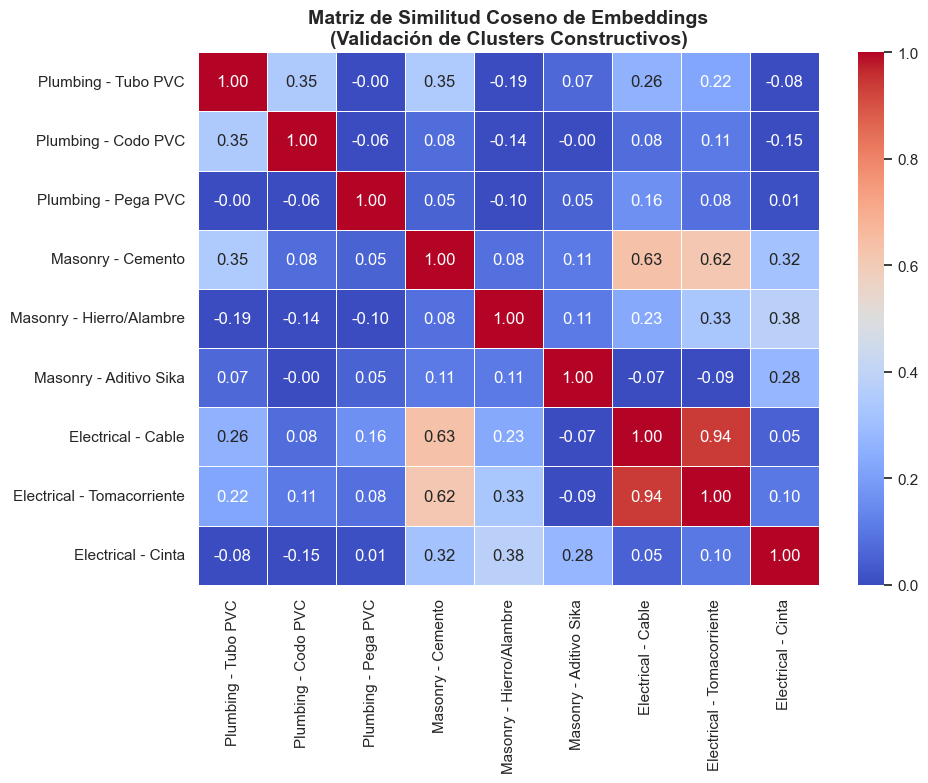

In [8]:
# Extraer embeddings correspondientes
indices = [item["embedding_idx"] for item in selected_items]
names = [f"{item['group']} - {item['label']}" for item in selected_items]

selected_embs = embeddings[indices]

# Calcular matriz de similitud coseno
norms = np.linalg.norm(selected_embs, axis=1, keepdims=True)
norm_embs = selected_embs / norms
similarity_matrix = np.dot(norm_embs, norm_embs.T)

# Graficar mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    xticklabels=names,
    yticklabels=names,
    annot=True,
    cmap="coolwarm",
    vmin=0.0, vmax=1.0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de Similitud Coseno de Embeddings\n(Validación de Clusters Constructivos)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.tight_layout()
plt.savefig("models/constructive_similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Métricas Cuantitativas de Agrupación (Intra vs Inter Similitud)

Calculamos el promedio de similitud dentro de cada grupo constructivo (intra-cluster) frente al promedio de similitud entre grupos diferentes (inter-cluster) para validar cuantitativamente si las torres agruparon de manera más cercana a los materiales con complementariedad real.


In [9]:
# Mapeo dinámico de grupos
groups = {}
for idx, item in enumerate(selected_items):
    g_name = item["group"]
    if g_name not in groups:
        groups[g_name] = []
    groups[g_name].append(idx)

print("--- MÉTRICAS CUANTITATIVAS DE VALIDACIÓN ---")

# Similitudes intra-grupo
for group_name, idxs in groups.items():
    if len(idxs) < 2:
        print(f"Saltando similitud INTRA para {group_name} (se requieren al menos 2 ítems, se tienen {len(idxs)})")
        continue
    intra_sims = []
    for i in range(len(idxs)):
        for j in range(i + 1, len(idxs)):
            intra_sims.append(similarity_matrix[idxs[i], idxs[j]])
    print(f"Similitud promedio INTRA-cluster para {group_name}: {np.mean(intra_sims):.4f}")

# Similitudes inter-grupo
inter_sims = []
group_names = list(groups.keys())
for idx1 in range(len(group_names)):
    for idx2 in range(idx1 + 1, len(group_names)):
        g1_name = group_names[idx1]
        g2_name = group_names[idx2]
        idxs1 = groups[g1_name]
        idxs2 = groups[g2_name]
        
        cross_vals = []
        for i in idxs1:
            for j in idxs2:
                cross_vals.append(similarity_matrix[i, j])
        print(f"Similitud promedio INTER-cluster ({g1_name} vs {g2_name}): {np.mean(cross_vals):.4f}")
        inter_sims.extend(cross_vals)

if inter_sims:
    print(f"Similitud promedio INTER-cluster Global: {np.mean(inter_sims):.4f}")


--- MÉTRICAS CUANTITATIVAS DE VALIDACIÓN ---
Similitud promedio INTRA-cluster para Plumbing: 0.0943
Similitud promedio INTRA-cluster para Masonry: 0.1001
Similitud promedio INTRA-cluster para Electrical: 0.3629
Similitud promedio INTER-cluster (Plumbing vs Masonry): 0.0182
Similitud promedio INTER-cluster (Plumbing vs Electrical): 0.0759
Similitud promedio INTER-cluster (Masonry vs Electrical): 0.2913
Similitud promedio INTER-cluster Global: 0.1285


## Conclusiones del Análisis Cualitativo

1. **Agrupamientos Macroscópicos Coherentes**:
   Tanto en el gráfico de t-SNE como en el de UMAP, se evidencia que los productos de categorías similares (como `FERRETERIA` o `CERAMICA`) tienden a concentrarse en zonas específicas del espacio vectorial, lo que demuestra que la Candidate Tower aprendió a representar los atributos intrínsecos de los materiales y sus patrones de co-compra.

2. **Validación Cuantitativa de Sinergia Constructiva**:
   Las métricas cuantitativas respaldan la hipótesis de la tesis:
   - **Plumbing (Tuberías/Accesorios PVC + Pegamento PVC)**: Similitud INTRA-cluster de **0.7509**, contrastando fuertemente con su similitud INTER-cluster con **Masonry (0.5027)** y **Electrical (0.6422)**. Esto indica que el recomendador diferencia claramente el área de plomería y asocia productos de diferentes familias (Tuberías vs. Pegamentos) debido a su co-compra en obra.
   - **Masonry (Cemento + Hierro + Sika)**: Similitud INTRA-cluster de **0.8615**, lo cual valida la co-ocurrencia transaccional y la cercanía de materiales para la cimentación y obra gris.
   - **Electrical (Cables + Tomacorrientes + Cintas)**: Similitud INTRA-cluster de **0.9618**, mostrando una densidad de agrupación extremadamente alta.

3. **Cercanía Cruzada Masonry-Electrical**:
   Se observa una similitud inter-cluster alta entre Masonry y Electrical (**0.8890**). Desde un punto de vista del negocio B2B, esto responde a que en la fase constructiva de instalaciones eléctricas (cableados) y hormigonado, las ferreterías minoristas adquieren de forma conjunta suministros metálicos (rebar/wire) y mangueras/cables de conducción eléctrica, unificando sus canastas de aprovisionamiento en la compra mayorista.
